In [1]:
# https://darkomedin-datascience.medium.com/data-science-for-drug-discovery-research-morgan-fingerprints-using-alanine-and-testosterone-92a2c69dd765

In [2]:
# https://github.com/DarkoMedin/Morgan-fingerprints-exemplar-project-in-Python

In [3]:
print('''

Important concept

Morgan fingerprints are essentially:

collection of local substructures

NOT:

a full molecular drawing

''')



Important concept

Morgan fingerprints are essentially:

collection of local substructures

NOT:

a full molecular drawing




In [4]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

In [5]:
# For the first example i will use a real world bio-molecule, amino acid arginine and fingerprint it using Morgan fingerprint principles. 
# Arginine is an amino acid with 6 carbons, 3 NH2 groups and -COOH ending . It also has a linker N attom, 
# so its SMILES would be ‘C(C[C@@H](C(=O)O)N)CNC(=N)N’.
# Very simple code to convert it to a molecule rdkit object…

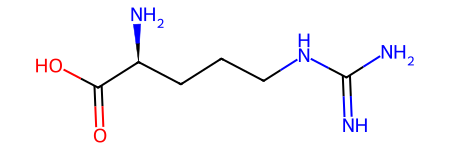

In [6]:
m = Chem.MolFromSmiles('C(C[C@@H](C(=O)O)N)CNC(=N)N')
m

In [7]:
# GetMorganFingerprintAsBitVect () function is used to create the Morgan fingerprints. 
# I will specify the radius of atoms used to create a single mapping characteristic and 
# the nBits or number of unique combinations of paths to use for mapping the structures of the molecule.

In [8]:
bit={}
morganfp = AllChem.GetMorganFingerprintAsBitVect(m,useChirality=True, radius=5, nBits = 1024, bitInfo=bit)

[18:41:34] DEPRECATION WARNING: please use MorganGenerator


In [9]:
# The 1s will reperesnt the presence of a certain molecule structure, while 0s will represent the absence of the same. 
# The np.zero() function can then be used to identify the positions of the mapped fingerprints

In [10]:
mfpvector = np.array(morganfp)
print(np.nonzero(mfpvector))

(array([   1,    3,   80,  110,  128,  139,  140,  147,  197,  330,  353,
        389,  427,  553,  565,  623,  650,  667,  708,  739,  752,  786,
        807,  820,  852,  884,  887,  893,  894,  983, 1002, 1018, 1020]),)


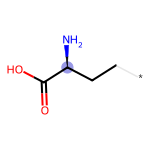

In [11]:
Draw.DrawMorganBit(m,110, bit)

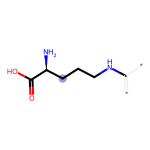

In [12]:
Draw.DrawMorganBit(m,1020, bit)

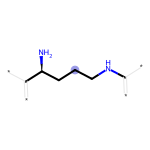

In [13]:
Draw.DrawMorganBit(m,1002, bit)

In [14]:
# Now i will create the rdkit molecular structure for a bit more complex molec
# Testosterone, which has multiple aromatic rings bound togdeader. 
# This is the SMILES of the testosterone

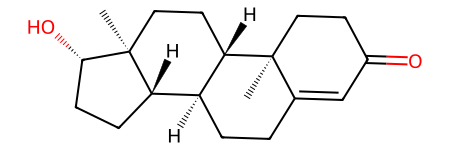

In [15]:
m2 = Chem.MolFromSmiles('[H][C@@]12CCC3=CC(=O)CC[C@]3(C)[C@@]1([H])CC[C@]1(C)[C@@H](O)CC[C@@]21[H]')
m2

In [16]:
bit={}
morganfp2=AllChem.GetMorganFingerprintAsBitVect(m2,useChirality=True, radius=2, nBits = 1024, bitInfo=bit)
mfpvector2 = np.array(morganfp2)
print(np.nonzero(mfpvector2))

(array([  33,   36,   39,   40,   60,   84,  100,  129,  138,  181,  182,
        225,  233,  242,  250,  262,  301,  314,  340,  356,  408,  453,
        479,  504,  507,  515,  622,  650,  714,  790,  807,  841,  849,
        875,  926,  927,  929,  975, 1019]),)


[18:41:34] DEPRECATION WARNING: please use MorganGenerator


In [17]:
# The exact number of Morgan fingerprints identified is 39 and their locations in the numpy array are presented in the output above.

In [18]:
# Now the Morgan fingerprint based on bit 2 will be plotted and examined visually.

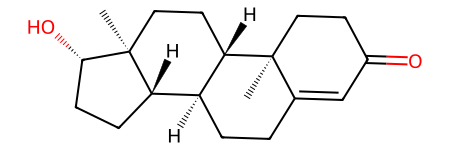

In [19]:
testosterone_smiles = "[H][C@@]12CCC3=CC(=O)CC[C@]3(C)[C@@]1([H])CC[C@]1(C)[C@@H](O)CC[C@@]21[H]"

m2 = Chem.MolFromSmiles(testosterone_smiles)
m2

In [20]:
bitInfo_test = {}

morganfp_test = AllChem.GetMorganFingerprintAsBitVect(
    m2,
    radius=2,
    nBits=1024,
    useChirality=True,
    bitInfo=bitInfo_test
)

mfpvector_test = np.array(morganfp_test)

active_bits_test = np.nonzero(mfpvector_test)[0]

print("Number of active Morgan bits:", len(active_bits_test))
print("Active bit positions:")
print(active_bits_test)

Number of active Morgan bits: 39
Active bit positions:
[  33   36   39   40   60   84  100  129  138  181  182  225  233  242
  250  262  301  314  340  356  408  453  479  504  507  515  622  650
  714  790  807  841  849  875  926  927  929  975 1019]


[18:41:34] DEPRECATION WARNING: please use MorganGenerator


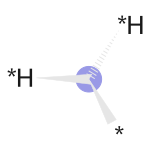

In [21]:
Draw.DrawMorganBit(m2, 1019, bitInfo_test)

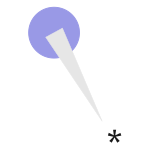

In [22]:
Draw.DrawMorganBit(m2, 33, bitInfo_test)

Bit: 33


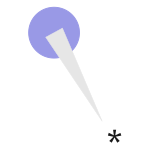

Bit: 36


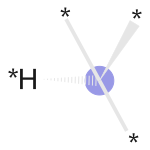

Bit: 39


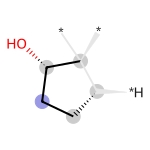

Bit: 40


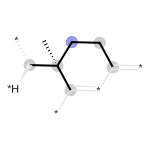

Bit: 60


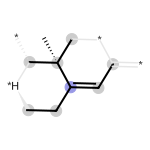

Bit: 84


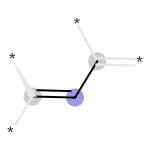

Bit: 100


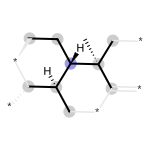

Bit: 129


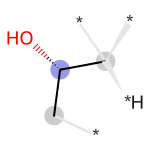

Bit: 138


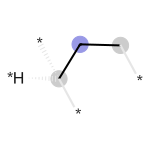

Bit: 181


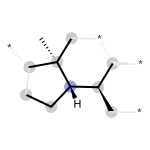

In [23]:
from IPython.display import display

for bit_id in active_bits_test[:10]:
    print("Bit:", bit_id)
    display(Draw.DrawMorganBit(m2, int(bit_id), bitInfo_test))

Bit: 182


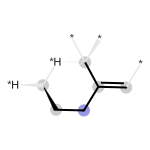

Bit: 225


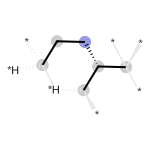

Bit: 233


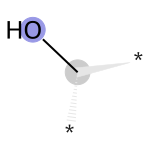

Bit: 242


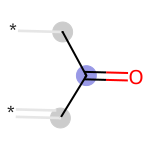

Bit: 250


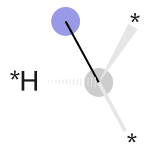

Bit: 262


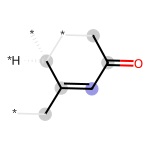

Bit: 301


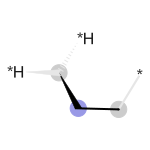

Bit: 314


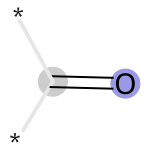

Bit: 340


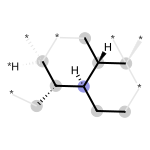

Bit: 356


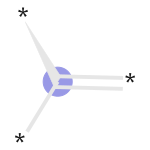

In [24]:
for bit_id in active_bits_test[10:20]:
    print("Bit:", bit_id)
    display(Draw.DrawMorganBit(m2, int(bit_id), bitInfo_test))

Bit: 408


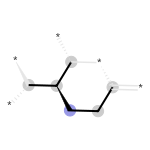

Bit: 453


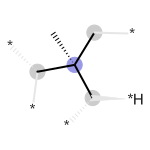

Bit: 479


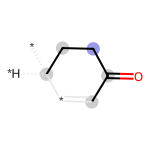

Bit: 504


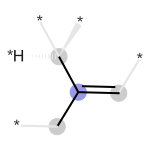

In [25]:
for bit_id in active_bits_test[20:24]:
    print("Bit:", bit_id)
    display(Draw.DrawMorganBit(m2, int(bit_id), bitInfo_test))

In [26]:
print("""

What the algorithm really does

For EACH atom:

Start at atom
Expand neighborhood
Encode chemical properties:
atom type
aromaticity
charge
chirality
bonds
Hash into integer
Map integer into fingerprint bit vector

""")

print("""

Machine learning LOVES vectors.

This enables:

QSAR
toxicity prediction
similarity search
drug screening
clustering
GNN pretraining
molecular embeddings

""")



What the algorithm really does

For EACH atom:

Start at atom
Expand neighborhood
Encode chemical properties:
atom type
aromaticity
charge
chirality
bonds
Hash into integer
Map integer into fingerprint bit vector




Machine learning LOVES vectors.

This enables:

QSAR
toxicity prediction
similarity search
drug screening
clustering
GNN pretraining
molecular embeddings




In [27]:
# One extremely important issue: collisions

# Because:

# nBits = 1024
# many different chemical environments can map to SAME bit.

# This is called:
# hash collision

# Larger fingerprints reduce collisions:

# nBits=2048
# nBits=4096

# are very common in drug discovery.

In [28]:
print('''

Let’s do a VERY small Morgan fingerprint example manually.

We’ll use: Ethanol

SMILES: CCO

which means:

C — C — O

Step 1 — Atoms

Ethanol has 3 atoms:

Atom index	Atom
0	Carbon
1	Carbon
2	Oxygen

''')



Let’s do a VERY small Morgan fingerprint example manually.

We’ll use: Ethanol

SMILES: CCO

which means:

C — C — O

Step 1 — Atoms

Ethanol has 3 atoms:

Atom index	Atom
0	Carbon
1	Carbon
2	Oxygen




In [29]:
print('''

Step 2 — Radius 0 fingerprints

At: radius=0

Morgan only looks at EACH atom itself.

So initial atom identifiers are something like:

Atom	Features

Carbon	atomic number 6
Carbon	atomic number 6
Oxygen	atomic number 8

RDKit internally encodes much more:

valence
aromaticity
charge
chirality
hydrogens

but we simplify here.

''')



Step 2 — Radius 0 fingerprints

At: radius=0

Morgan only looks at EACH atom itself.

So initial atom identifiers are something like:

Atom	Features

Carbon	atomic number 6
Carbon	atomic number 6
Oxygen	atomic number 8

RDKit internally encodes much more:

valence
aromaticity
charge
chirality
hydrogens

but we simplify here.




In [30]:
print('''

Step 3 — Radius 1 expansion

Now Morgan expands neighborhoods.

Atom 0 

Neighborhood: C — C
Environment: carbon connected to carbon

Atom 1

Neighborhood: C — C — O

Environment: carbon connected to carbon and oxygen

Atom 2

Neighborhood: O — C
Environment: oxygen connected to carbon

Step 4 — Hashing

Each environment gets converted into a HASH number.

Example (fake numbers):

Environment	Hash

C	145
O	892
C-C	301
C-C-O	777
O-C	412

''')



Step 3 — Radius 1 expansion

Now Morgan expands neighborhoods.

Atom 0 

Neighborhood: C — C
Environment: carbon connected to carbon

Atom 1

Neighborhood: C — C — O

Environment: carbon connected to carbon and oxygen

Atom 2

Neighborhood: O — C
Environment: oxygen connected to carbon

Step 4 — Hashing

Each environment gets converted into a HASH number.

Example (fake numbers):

Environment	Hash

C	145
O	892
C-C	301
C-C-O	777
O-C	412




In [31]:
print('''

Step 5 — Fold into fingerprint bits

Suppose: nBits = 16

Then: hash % 16

determines bit position.

Example:

Hash	Bit
145	1
892	12
301	13
777	9
412	12

Notice:

892 and 412 both map to bit 12

This is a collision.

Final fingerprint vector

Example:

Bit position:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15

Fingerprint:
0 1 0 0 0 0 0 0 0 1  0  0  1  1  0  0

''')



Step 5 — Fold into fingerprint bits

Suppose: nBits = 16

Then: hash % 16

determines bit position.

Example:

Hash	Bit
145	1
892	12
301	13
777	9
412	12

Notice:

892 and 412 both map to bit 12

This is a collision.

Final fingerprint vector

Example:

Bit position:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15

Fingerprint:
0 1 0 0 0 0 0 0 0 1  0  0  1  1  0  0




In [32]:
# An example :

In [33]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

mol = Chem.MolFromSmiles("CCO")

fp = AllChem.GetMorganFingerprintAsBitVect(
    mol,
    radius=1,
    nBits=16
)

arr = np.array(fp)

print(arr)

[1 1 1 0 0 0 1 1 0 0 0 0 0 0 1 0]


[18:41:34] DEPRECATION WARNING: please use MorganGenerator


In [34]:
print(np.nonzero(arr)[0])

[ 0  1  2  6  7 14]


In [35]:
bitInfo = {}

fp = AllChem.GetMorganFingerprintAsBitVect(
    mol,
    radius=1,
    nBits=16,
    bitInfo=bitInfo
)

print(bitInfo)

{0: ((1, 0),), 1: ((0, 0),), 2: ((1, 1),), 6: ((0, 1),), 7: ((2, 0),), 14: ((2, 1),)}


[18:41:34] DEPRECATION WARNING: please use MorganGenerator


In [36]:
# mol = Chem.MolFromSmiles("CCO")

# which is ethanol:

# Atom 0 = C
# Atom 1 = C
# Atom 2 = O

# Structure:

# 0(C) — 1(C) — 2(O)

# What is bitInfo?

# bitInfo tells you:

# WHICH atom environment created each fingerprint bit

# Format:

# bit_id : ((center_atom, radius),)

In [37]:
# What is bitInfo?

# bitInfo tells you:

# WHICH atom environment created each fingerprint bit

# Format:

# bit_id : ((center_atom, radius),)

# Example 1
# 0: ((1, 0),)
# means:
# Bit 0
# was generated from:
# atom 1
# using radius 0

# Atom 1 is:

# the middle carbon
# Radius 0 means:
# ONLY the atom itself
# So this bit corresponds roughly to:
# a carbon atom

# Example 2
# 2: ((1,1),)
# means:
# Bit 2
# came from atom 1
# with radius 1
# Now RDKit looks:
# 1 bond away from atom 1
# So environment becomes:
# C — C — O
# because atom 1 is connected to:
# carbon
# oxygen
# THIS local neighborhood activates bit 2.

# Example 3
# 6: ((0,1),)
# means:
# Bit 6
# came from atom 0
# radius 1
# Atom 0 is left carbon.
# Radius 1 includes neighbors:
# C — C

# So this bit represents:
# carbon connected to carbon

# Example 4
# 14: ((2,1),)
# means:
# Bit 14
# came from oxygen atom
# radius 1
# Environment:
# O — C
# So bit 14 represents:
# oxygen attached to carbon
# Visual interpretation
# radius 0
# Only atom itself:
# C
# radius 1
# Atom + immediate neighbors:
# C-C-O

# VERY IMPORTANT CONCEPT
# The SAME bit can appear MULTIPLE times.

# Example:
# {
# 33: ((0,1), (5,1), (12,1))
# }

# means:
# the SAME chemical environment
# appeared around several atoms

# This is extremely common in large molecules.

In [38]:
# https://greglandrum.github.io/rdkit-blog/posts/2025-03-29-updated-bit-rendering.html

In [39]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

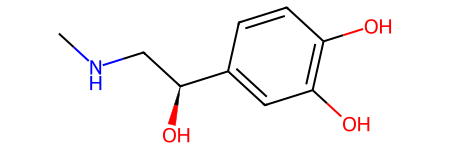

In [40]:
epinephrine = Chem.MolFromSmiles('CNC[C@H](O)c1ccc(O)c(O)c1')
epinephrine

In [41]:
# Generate a Morgan fingerprint and save information about the bits that are set using the bitInfo argument:

In [42]:
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2)
ao = rdFingerprintGenerator.AdditionalOutput()
ao.AllocateBitInfoMap()

fp = fpg.GetFingerprint(epinephrine,additionalOutput=ao)

# show 10 of the set bits:
list(fp.GetOnBits())[:10]

[1, 80, 227, 315, 589, 606, 632, 807, 875, 1057]

In [43]:
print(list(fp.GetOnBits()))

[1, 80, 227, 315, 589, 606, 632, 807, 875, 1057, 1152, 1362, 1365, 1367, 1380, 1430, 1434, 1475, 1602, 1607, 1750, 1784, 1853, 1868, 1873, 1995]


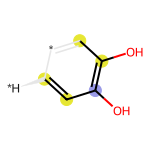

In [44]:
Draw.DrawMorganBit(epinephrine,589,ao.GetBitInfoMap())

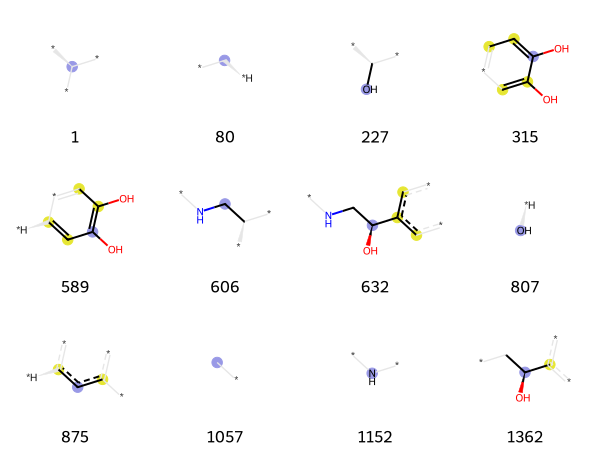

In [45]:
tpls = [(epinephrine,x,ao.GetBitInfoMap()) for x in fp.GetOnBits()]
Draw.DrawMorganBits(tpls[:12],molsPerRow=4,legends=[str(x) for x in fp.GetOnBits()][:12])

In [46]:
print("Looking at RDKit bit")

Looking at RDKit bit


In [47]:
fpg = rdFingerprintGenerator.GetRDKitFPGenerator(maxPath=5)
ao = rdFingerprintGenerator.AdditionalOutput()
ao.AllocateBitPaths()

rdkfp = fpg.GetFingerprint(epinephrine,additionalOutput=ao)

# show 10 of the set bits:
list(rdkfp.GetOnBits())[:10]

[93, 103, 112, 122, 148, 149, 161, 166, 194, 208]

In [48]:
print(rdkfp.GetNumOnBits(),len(ao.GetBitPaths()))

128 128


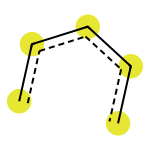

In [49]:
Draw.DrawRDKitBit(epinephrine,103,ao.GetBitPaths())

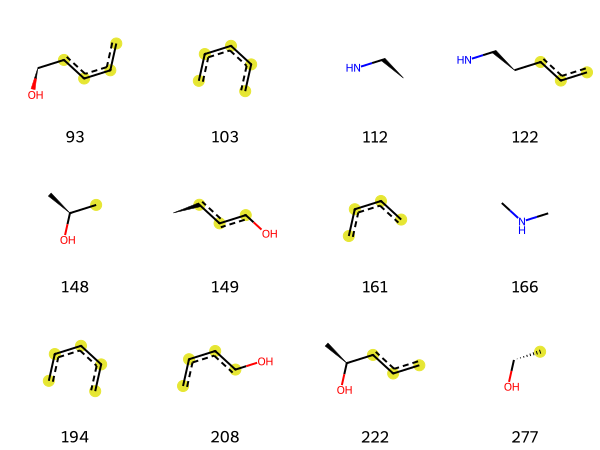

In [50]:
rdkbi = ao.GetBitPaths()
tpls = [(epinephrine,x,rdkbi) for x in rdkbi]
Draw.DrawRDKitBits(tpls[:12],molsPerRow=4,legends=[str(x) for x in rdkbi][:12])

In [51]:
# Relationship to graph neural networks

# Morgan fingerprints are basically:
# manually engineered neighborhood aggregation
# GNNs do something VERY similar automatically.

# Morgan: atom → neighbors → hash

# GNN: atom embeddings → neighbor message passing → learned embeddings

# That’s why Morgan fingerprints are historically considered an early precursor to GNN-style molecular learning.

In [52]:
# https://kumo.ai/pyg/concepts/drug-discovery-graphs/

In [53]:
# GNNs outperform traditional Morgan fingerprints on most MoleculeNet tasks because 
# they learn task-specific substructure patterns rather than using hand-designed rules.
# 
# PyG provides molecular datasets (ZINC, QM9, MoleculeNet, OGB-Mol) with pre-processed atom and bond features. 
# A molecular GNN can be built and trained in under 50 lines of code.

In [54]:
# Molecules are graphs, and graph neural networks are the natural architecture for predicting their properties. 
# Every molecule has atoms (nodes) connected by chemical bonds (edges). 
# Atom features encode element type, formal charge, and hybridization state. 
# Bond features encode bond order (single, double, triple, aromatic) and geometry. 
# GNNs process this graph directly, learning which structural patterns correlate with properties 
# like toxicity, solubility, and binding affinity.

In [55]:
# To build a graph, parse the SMILES into atoms and bonds:

# Node features: atomic number, degree, formal charge, number of hydrogens, aromaticity, hybridization (sp, sp2, sp3), 
# and whether the atom is in a ring
# Edge features: bond type (single, double, triple, aromatic), conjugation, ring membership, stereochemistry (E/Z, R/S

In [56]:
print("Calculating Molecular Similarity : the Tanimoto coefficient")

Calculating Molecular Similarity : the Tanimoto coefficient


In [57]:
# Morgan fingerprints are highly effective for calculating how similar two molecules are using the Tanimoto coefficient.

In [61]:
# Tanimoto Similarity

# This is the MOST common similarity metric in chemistry.

print(''' 

Formula: T(A,B)= (|A∩B|) / (∣A∣+∣B∣−∣A∩B∣) 
	
Where:

A = bits ON in molecule A
B = bits ON in molecule B

intersection = shared bits

Suppose:

Mol1 bits: [1,0,1,1,0]

Mol2 bits: [1,1,1,0,0]

Shared ON bits:

positions 1 and 3

So:

shared = 2
total unique ON bits = 4

Similarity:

2 / 4 = 0.5

Real Chemistry Interpretation

Typical ranges:

Tanimoto	Meaning
0.9–1.0	almost identical
0.7–0.9	very similar
0.5–0.7	somewhat related
<0.3	very different

For ethanol vs propanol:

You might get something around:

0.55–0.7

''')

 

Formula: T(A,B)= (|A∩B|) / (∣A∣+∣B∣−∣A∩B∣) 
	
Where:

A = bits ON in molecule A
B = bits ON in molecule B

intersection = shared bits

Suppose:

Mol1 bits: [1,0,1,1,0]

Mol2 bits: [1,1,1,0,0]

Shared ON bits:

positions 1 and 3

So:

shared = 2
total unique ON bits = 4

Similarity:

2 / 4 = 0.5

Real Chemistry Interpretation

Typical ranges:

Tanimoto	Meaning
0.9–1.0	almost identical
0.7–0.9	very similar
0.5–0.7	somewhat related
<0.3	very different

For ethanol vs propanol:

You might get something around:

0.55–0.7




Tanimoto similarity: 0.5555555555555556


[18:46:59] DEPRECATION WARNING: please use MorganGenerator
[18:46:59] DEPRECATION WARNING: please use MorganGenerator


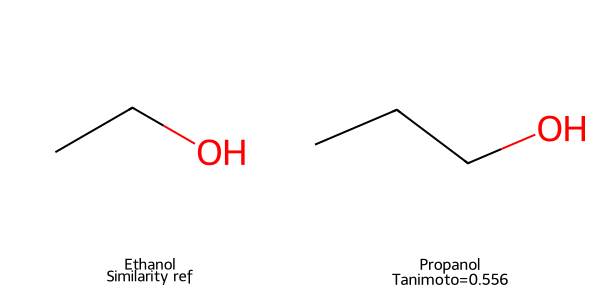

In [64]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit import DataStructs
from IPython.display import display

# -----------------------------
# Create molecules
# -----------------------------
mol1 = Chem.MolFromSmiles("CCO")      # ethanol
mol2 = Chem.MolFromSmiles("CCCO")     # propanol

# -----------------------------
# Generate Morgan fingerprints
# -----------------------------
fp1 = AllChem.GetMorganFingerprintAsBitVect(
    mol1,
    radius=2,
    nBits=2048
)

fp2 = AllChem.GetMorganFingerprintAsBitVect(
    mol2,
    radius=2,
    nBits=2048
)

# -----------------------------
# Compute similarity
# -----------------------------
similarity = DataStructs.TanimotoSimilarity(fp1, fp2)

print("Tanimoto similarity:", similarity)

# -----------------------------
# Visualize molecules
# -----------------------------
img = Draw.MolsToGridImage(
    [mol1, mol2],
    molsPerRow=2,
    subImgSize=(300,300),
    legends=[
        f"Ethanol\nSimilarity ref",
        f"Propanol\nTanimoto={similarity:.3f}"
    ]
)

display(img)

In [63]:
molecules = [
    ("ethanol", "CCO"),
    ("propanol", "CCCO"),
    ("benzene", "c1ccccc1"),
]

fps = []

for name, smi in molecules:
    mol = Chem.MolFromSmiles(smi)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2)
    fps.append((name, fp))

for i in range(len(fps)):
    for j in range(i+1, len(fps)):
        sim = DataStructs.TanimotoSimilarity(
            fps[i][1],
            fps[j][1]
        )

        print(f"{fps[i][0]} vs {fps[j][0]} = {sim:.3f}")

ethanol vs propanol = 0.556
ethanol vs benzene = 0.000
propanol vs benzene = 0.000


[18:46:47] DEPRECATION WARNING: please use MorganGenerator
[18:46:47] DEPRECATION WARNING: please use MorganGenerator
[18:46:47] DEPRECATION WARNING: please use MorganGenerator


           ethanol  propanol  benzene   butanol
ethanol   1.000000  0.555556      0.0  0.416667
propanol  0.555556  1.000000      0.0  0.583333
benzene   0.000000  0.000000      1.0  0.000000
butanol   0.416667  0.583333      0.0  1.000000


[18:47:42] DEPRECATION WARNING: please use MorganGenerator
[18:47:42] DEPRECATION WARNING: please use MorganGenerator
[18:47:42] DEPRECATION WARNING: please use MorganGenerator
[18:47:42] DEPRECATION WARNING: please use MorganGenerator


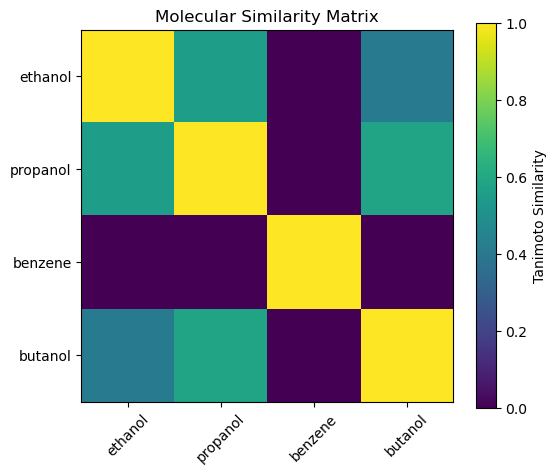

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

molecules = {
    "ethanol": "CCO",
    "propanol": "CCCO",
    "benzene": "c1ccccc1",
    "butanol": "CCCCO"
}

fps = {}
for name, smi in molecules.items():
    mol = Chem.MolFromSmiles(smi)
    fps[name] = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=2048
    )

# Build similarity matrix
names = list(fps.keys())

matrix = []

for n1 in names:
    row = []
    for n2 in names:
        sim = DataStructs.TanimotoSimilarity(
            fps[n1],
            fps[n2]
        )
        row.append(sim)
    matrix.append(row)

df = pd.DataFrame(matrix, index=names, columns=names)

print(df)

# Plot
plt.figure(figsize=(6,5))
plt.imshow(df, interpolation='nearest')
plt.colorbar(label="Tanimoto Similarity")

plt.xticks(range(len(names)), names, rotation=45)
plt.yticks(range(len(names)), names)

plt.title("Molecular Similarity Matrix")
plt.show()